# 01 · Data Cleaning

**Project:** Solar Power Forecasting with Machine Learning
**Dataset:** SKIPP'D (Stanford) — solar power measured every minute, 2017 to October 2019

**Goal of this notebook:** turn the raw file into a clean, trustworthy table we can model.
We never edit the raw file. We read it, fix problems in code, and save a new clean file.

Every problem we find is written down, with the reason for the fix. This is what makes the
project reproducible: anyone can run this notebook and get the same clean data.

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the project folder, whether the notebook runs from /notebooks or the project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "results" / "figures"
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

LOCAL_TZ = "America/Los_Angeles"   # Stanford, California
log = {}                           # we record every cleaning step here

## Step 1 · Load the raw data

There is one file per year (2017, 2018, 2019). Each has two columns: the time, and the power
in kilowatts (kW). We read all three and stack them into one table.

Note: the 2019 file ends on 27 October 2019. That is where the dataset ends.

In [26]:
files = sorted(RAW_DIR.glob("*_pv_raw.csv"))
print("Files found:", [f.name for f in files])

raw = pd.concat([pd.read_csv(f, parse_dates=["Date"]) for f in files], ignore_index=True)
raw = raw.rename(columns={"Date": "time_local", "Huang_E4102_kW": "power_kw"})

log["raw_rows"] = len(raw)
print(raw.shape)
raw.head()

Files found: ['2017_pv_raw.csv', '2018_pv_raw.csv', '2019_pv_raw.csv']
(1482241, 2)


,time_local,power_kw
0,2017-01-01 00:00:00,-0.084945
1,2017-01-01 00:01:00,-0.084945
2,2017-01-01 00:02:00,-0.084945
3,2017-01-01 00:03:00,-0.084945
4,2017-01-01 00:04:00,-0.084945


## Step 2 · Fix the time zone

The times are **local California time**, which uses daylight saving:

- **In March** clocks jump from 2:00 to 3:00 AM, so that hour is missing (every year).
- **In November** clocks go back, so 1:00–1:59 AM happens **twice** (120 rows for 60 minutes).
  This happens in 2017 and 2018. The 2019 data ends before November.

Local time with daylight saving is confusing for models. We convert everything to **UTC**,
which never jumps. In the file, each repeated minute appears twice in a row:
the first one is summer time (PDT), the second is winter time (PST).

In [27]:
dup_count = raw["time_local"].duplicated(keep=False).sum()
print("Rows with a repeated timestamp:", dup_count)

# First copy of a repeated minute = summer time (True), second copy = winter time (False)
is_summer_time = ~raw["time_local"].duplicated(keep="first")

time_utc = (raw["time_local"]
            .dt.tz_localize(LOCAL_TZ, ambiguous=is_summer_time.to_numpy())
            .dt.tz_convert("UTC"))

pv = pd.Series(raw["power_kw"].to_numpy(), index=pd.DatetimeIndex(time_utc, name="time_utc"),
               name="power_kw")

print("Repeated timestamps after fix:", pv.index.duplicated().sum())
log["dst_duplicates_fixed"] = int(dup_count)

Rows with a repeated timestamp: 240
Repeated timestamps after fix: 0


## Step 3 · Check for missing minutes

We build a complete minute-by-minute calendar in UTC and see which minutes have no reading.
The March daylight-saving hour is not really missing: it never existed in local time, and in UTC the calendar is continuous.

In [28]:
full_index = pd.date_range(pv.index.min(), pv.index.max(), freq="min", tz="UTC", name="time_utc")
pv = pv.reindex(full_index)

log["missing_minutes"] = int(pv.isna().sum())
print("Missing minutes:", log["missing_minutes"])

Missing minutes: 0


## Step 4 · Small negative values at night

At night the system uses a tiny amount of power (about −0.08 kW), so the meter reads slightly
below zero. A solar panel cannot *produce* negative power, so we set these values to 0.

In [29]:
negative = (pv < 0).sum()
pv = pv.clip(lower=0)

log["negative_values_set_to_zero"] = int(negative)
print("Negative readings set to 0:", negative)

Negative readings set to 0: 752519


## Step 5 · Days with no production (outages)

Some days show no power at all, even at noon. The sun still rose on those days, so this is a
**system or logging outage**, not real weather.

If we kept these as 0, the model would learn "sometimes sunny days give 0 power", which is wrong.
So we mark them as **missing (NaN)** instead.

In [30]:
local_day = pv.index.tz_convert(LOCAL_TZ).normalize()
daily_max = pv.groupby(local_day).max()

outage_days = daily_max[daily_max < 0.5].index
print(f"{len(outage_days)} outage days:")
print([d.strftime("%Y-%m-%d") for d in outage_days])

pv[np.isin(local_day, outage_days)] = np.nan
log["outage_days_removed"] = len(outage_days)

21 outage days:
['2017-01-01', '2017-01-02', '2017-01-22', '2017-01-23', '2017-03-10', '2017-03-11', '2017-03-12', '2017-03-18', '2017-03-19', '2017-12-30', '2017-12-31', '2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04', '2018-09-25', '2018-09-26', '2018-09-27', '2018-09-28', '2018-09-29', '2018-09-30']


## Step 6 · Frozen readings

Sometimes a logger "freezes" and repeats the exact same number for a long time.
Real solar power changes a little every minute during the day, so **60+ identical daytime
readings in a row** means the sensor was stuck. We mark those minutes as missing too.

In [31]:
run_id = (pv != pv.shift()).cumsum()
run_length = pv.groupby(run_id).transform("size")
frozen = (run_length >= 60) & (pv > 0.5)

pv[frozen] = np.nan
log["frozen_minutes_removed"] = int(frozen.sum())
print("Frozen daytime minutes removed:", frozen.sum())

Frozen daytime minutes removed: 52983


## Step 7 · Make an hourly version

Minute data is very detailed. For the first models (Levels 1–3) we use **hourly averages**,
because weather data is hourly too. The average power in kW over one hour equals the energy
in kWh produced in that hour.

Rule: an hour is only kept if at least **50 of its 60 minutes** are valid. Otherwise it is missing.
We keep the minute data too, for the sky-image stage later.

In [32]:
hourly = pv.resample("h").mean()
valid_minutes = pv.resample("h").count()
hourly[valid_minutes < 50] = np.nan
hourly.name = "energy_kwh"

log["hours_total"] = len(hourly)
log["hours_missing"] = int(hourly.isna().sum())
print(f"{len(hourly)} hours, {hourly.isna().sum()} missing")
hourly.describe()

24705 hours, 1395 missing


count    23310.000000
mean         5.898873
std          8.186354
min          0.000000
25%          0.000000
50%          0.061943
75%         12.189903
max         28.554184
Name: energy_kwh, dtype: float64

## Step 8 · Save the clean data

We save as **Parquet**, a fast, compact file format that also keeps the time zone.

In [33]:
pv.to_frame().to_parquet(PROCESSED / "pv_minute_clean.parquet")
hourly.to_frame().to_parquet(PROCESSED / "pv_hourly_clean.parquet")
print("Saved to", PROCESSED.relative_to(ROOT))

Saved to data/processed


## Step 9 · Look at the clean data

Two charts:

1. **Daily energy across all years.** Shows the seasons, and where the outage gaps are.
2. **Heatmap of hour × day.** Each column is a day, each row is an hour. Brighter means more
   power, and grey means missing. You can see the days getting longer in summer, and cloudy days as dark stripes.

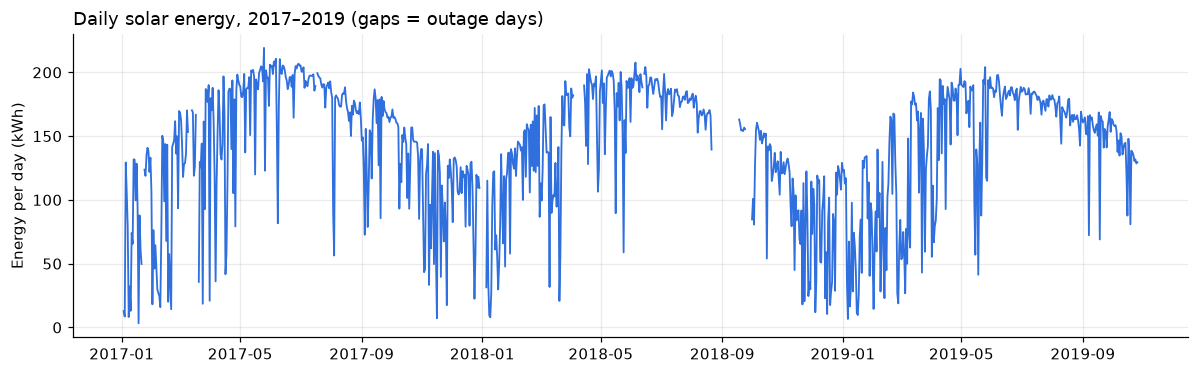

In [34]:
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

hourly_local = hourly.tz_convert(LOCAL_TZ)
daily_kwh = hourly_local.resample("D").sum(min_count=18)   # needs most hours present

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(daily_kwh.index, daily_kwh.values, color="#2F6FDE", linewidth=1.2)
ax.set_title("Daily solar energy, 2017–2019 (gaps = outage days)", loc="left")
ax.set_ylabel("Energy per day (kWh)")
fig.tight_layout()
fig.savefig(FIGURES / "01_daily_energy.png")
plt.show()

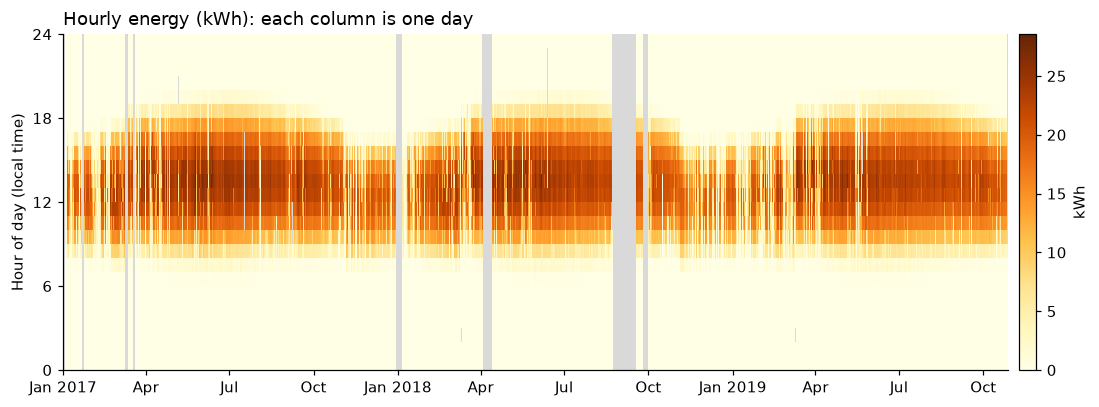

In [35]:
grid = (hourly_local.to_frame()
        .assign(day=lambda d: d.index.normalize(), hour=lambda d: d.index.hour)
        .pivot_table(index="hour", columns="day", values="energy_kwh", dropna=False))

fig, ax = plt.subplots(figsize=(11, 3.8))
cmap = plt.get_cmap("YlOrBr").copy()
cmap.set_bad("#D9D9D9")                                    # missing hours shown in grey
im = ax.imshow(grid.values, aspect="auto", origin="lower", cmap=cmap,
               interpolation="nearest", extent=[0, grid.shape[1], 0, 24])
days = grid.columns.tz_localize(None) if grid.columns.tz is not None else grid.columns
ticks = [i for i, d in enumerate(days) if d.day == 1 and d.month in (1, 4, 7, 10)]
ax.set_xticks(ticks)
ax.set_xticklabels([days[i].strftime("%b %Y") if days[i].month == 1 else days[i].strftime("%b") for i in ticks])
ax.set_yticks([0, 6, 12, 18, 24])
ax.set_ylabel("Hour of day (local time)")
ax.set_title("Hourly energy (kWh): each column is one day", loc="left")
ax.grid(False)
fig.colorbar(im, ax=ax, label="kWh", pad=0.01)
fig.tight_layout()
fig.savefig(FIGURES / "01_hour_by_day_heatmap.png")
plt.show()

## Summary of cleaning

This table goes straight into the README.

In [36]:
pd.Series(log, name="count").to_frame()

,count
raw_rows,1482241
dst_duplicates_fixed,240
missing_minutes,0
negative_values_set_to_zero,752519
outage_days_removed,21
frozen_minutes_removed,52983
hours_total,24705
hours_missing,1395


In [37]:
# Hours available per year, after cleaning
per_year = pd.DataFrame({
    "hours": hourly.groupby(hourly.index.year).size(),
    "missing": hourly.isna().groupby(hourly.index.year).sum(),
})
per_year

,hours,missing
time_utc,,
2017,8752,275
2018,8760,1114
2019,7193,6


**What we learned**

- The data is good quality overall: almost three years, one reading per minute.
- The problems were daylight saving time, small negative night values, outage days,
  and frozen readings. Each one is fixed with a clear rule.
- Power follows the seasons: long, strong summer days and short winter days, with cloudy days
  showing up as sudden drops.

**Next notebook:** `02_baselines.ipynb`, the simplest possible forecasts that any real model must beat.